In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
df=pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


DATA IDENTIFYING AND UNDERSTANDING

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [7]:
df.shape

(10000, 14)

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 14


In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop(['RowNumber','CustomerId','Surname'],
        axis=1,
        inplace=True)

df.head() #data cleaning

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df.shape

(10000, 11)

In [15]:
num_cols = ['CreditScore',
            'Age',
            'Tenure',
            'Balance',
            'NumOfProducts',
            'EstimatedSalary']

cat_cols = ['Geography',
            'Gender',
            'HasCrCard',
            'IsActiveMember',
            'Exited']

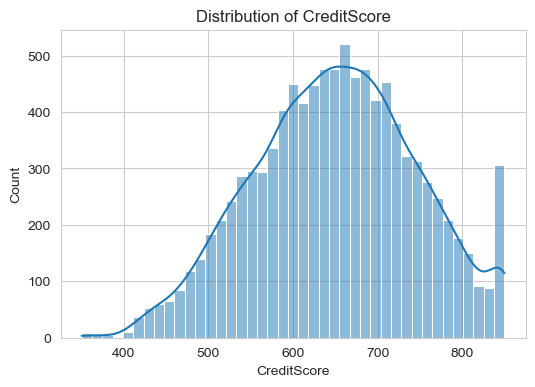

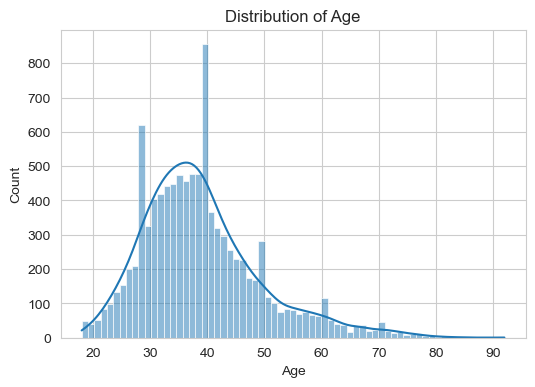

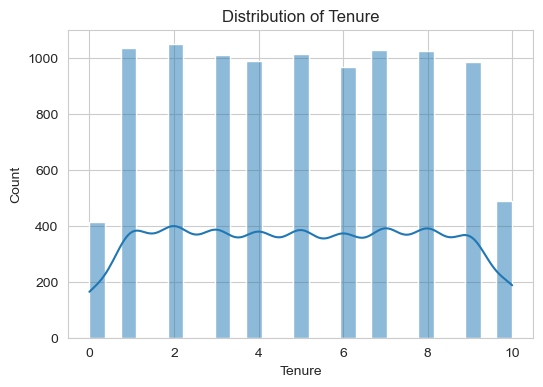

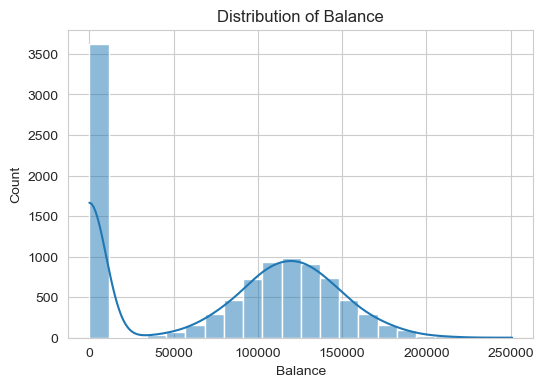

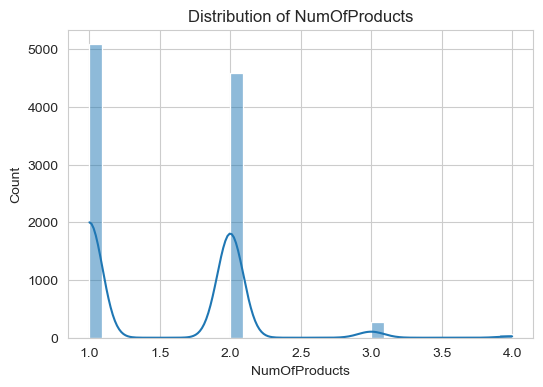

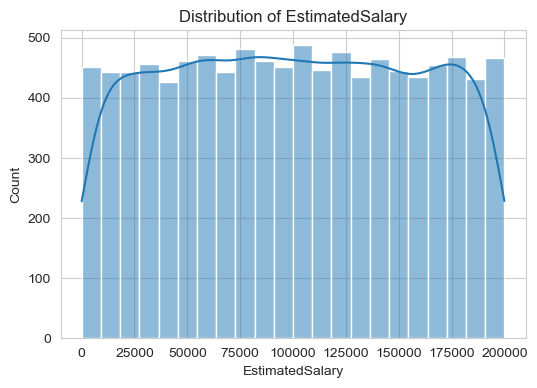

In [16]:
for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col],
                 kde=True)
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

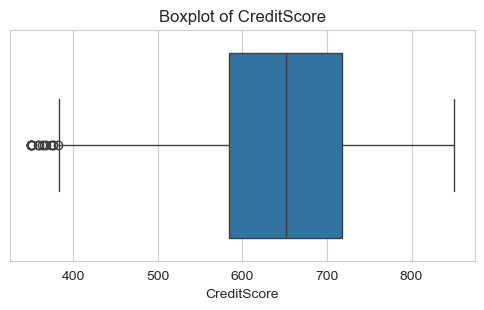

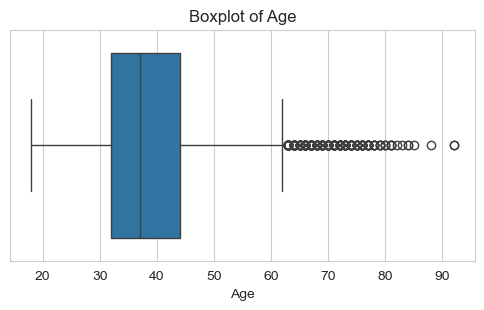

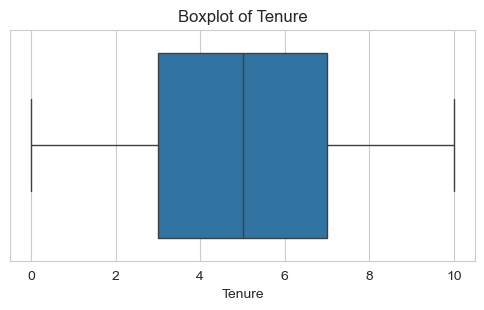

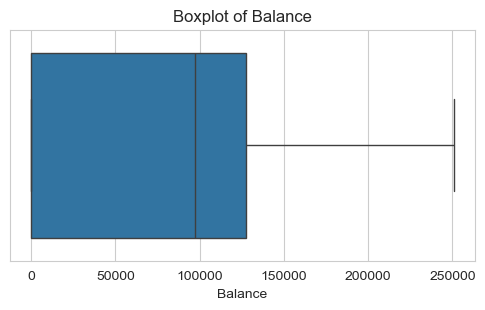

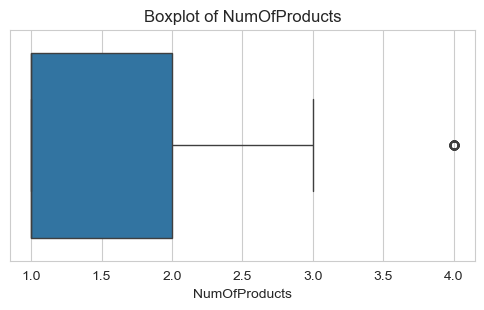

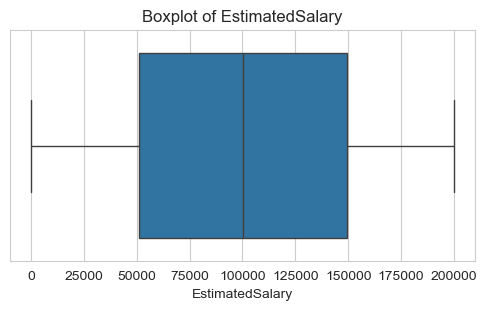

In [17]:
for col in num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

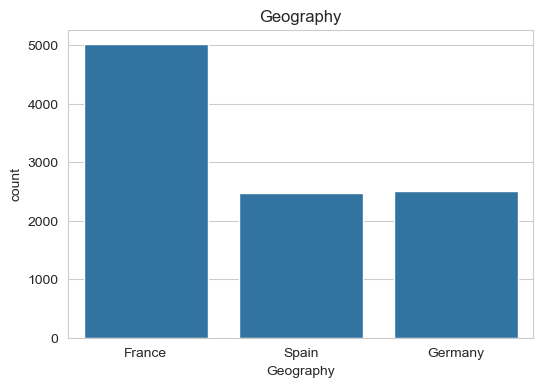

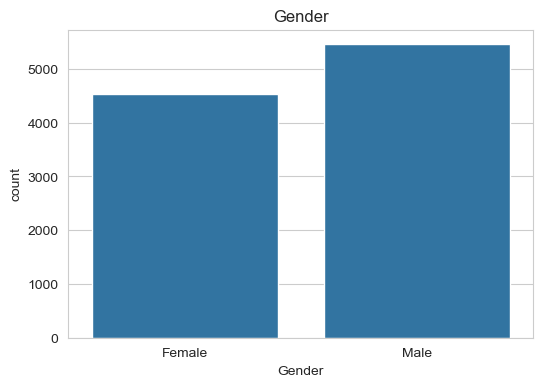

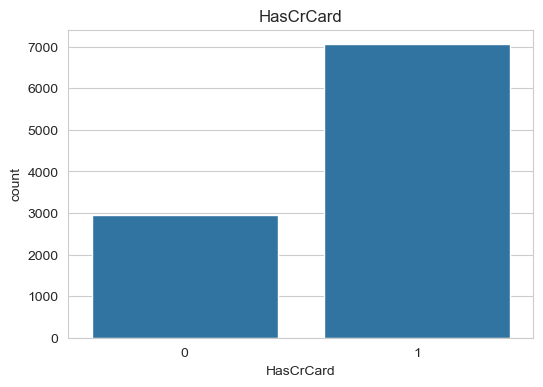

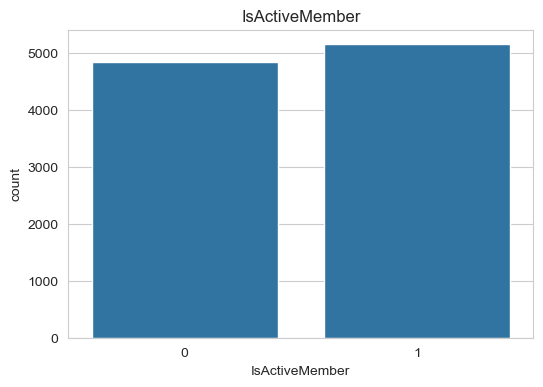

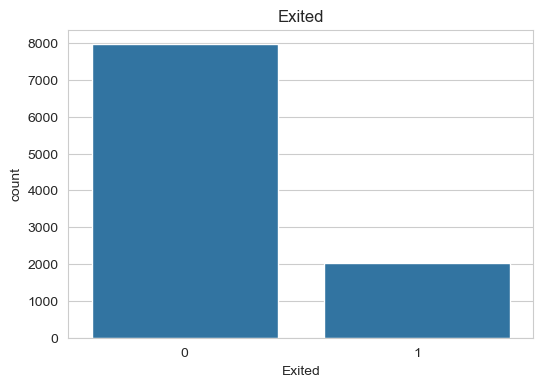

In [18]:
for col in cat_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(x=df[col])
    
    plt.title(col)
    
    plt.show()

In [37]:
for col in cat_cols:
    
    print("\n")
    
    print(
        round(
            df[col].value_counts(normalize=True)*100,
            2
        )
    )



Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64


HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64


IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


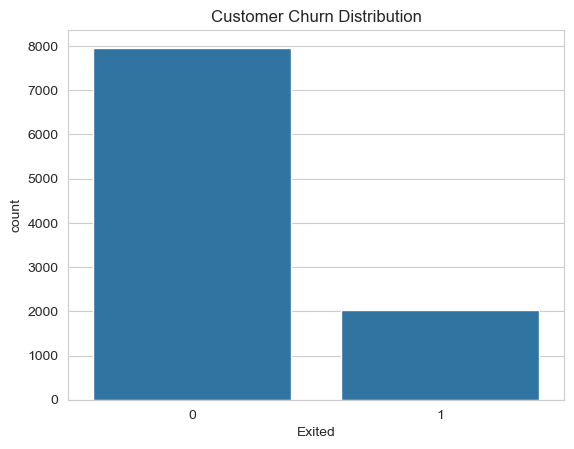

In [20]:
sns.countplot(x='Exited',
              data=df)

plt.title("Customer Churn Distribution")
plt.show()#churn count

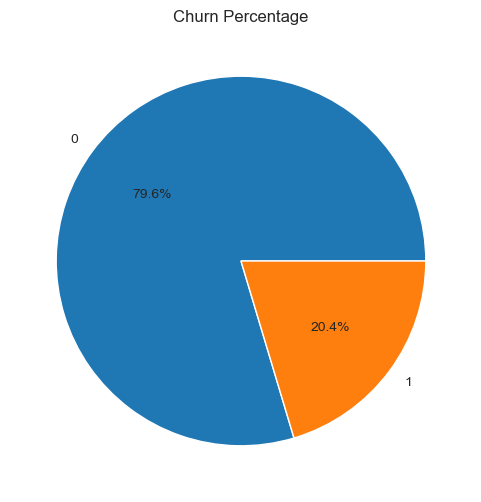

In [21]:
df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Churn Percentage")
plt.show()

In [22]:
churn_rate = df['Exited'].mean()*100

print("Churn Rate :", round(churn_rate,2),"%")

Churn Rate : 20.37 %


NOW WE WILL DO BIVARIATE ANALYSIS

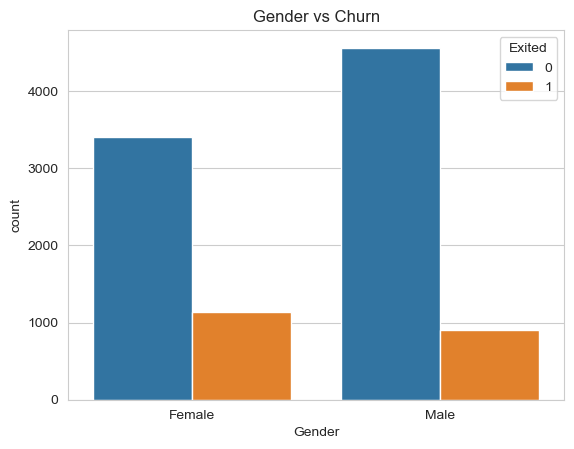

In [23]:
sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title("Gender vs Churn")
plt.show()

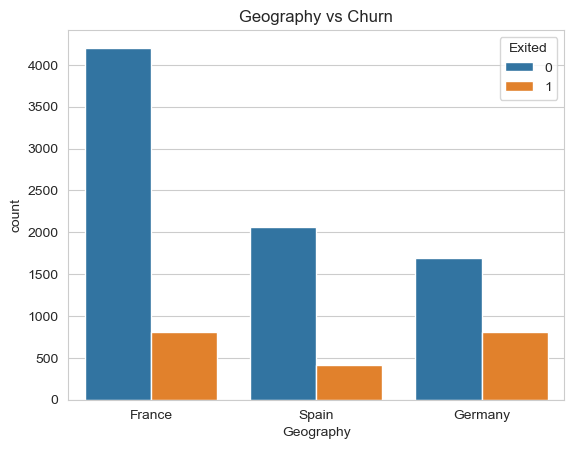

In [24]:
sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography vs Churn")
plt.show()

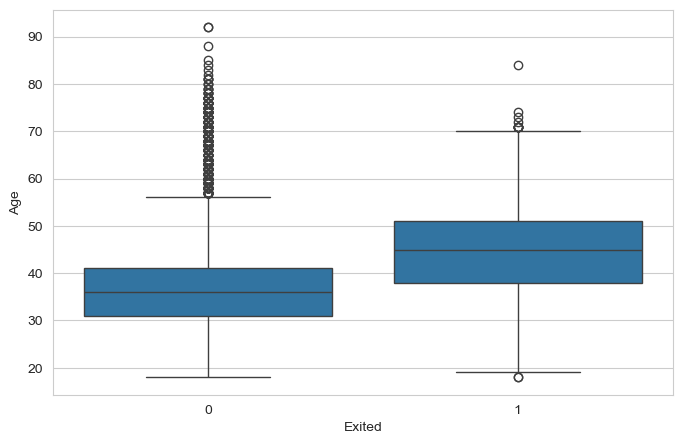

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

plt.show()

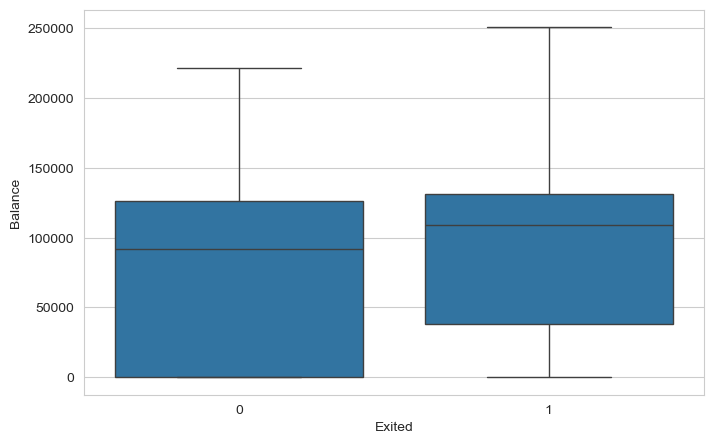

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.show()

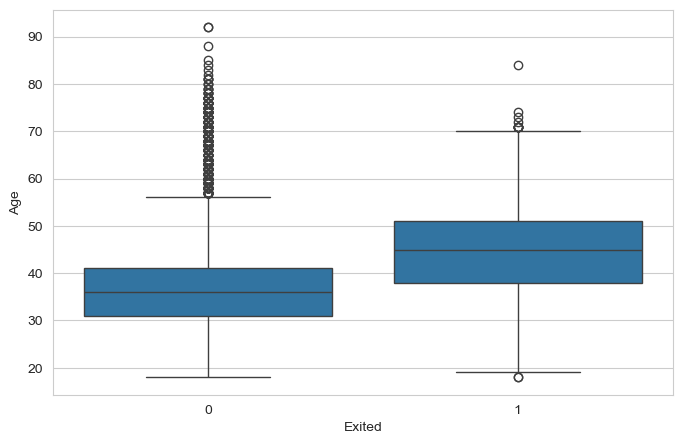

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

plt.show()

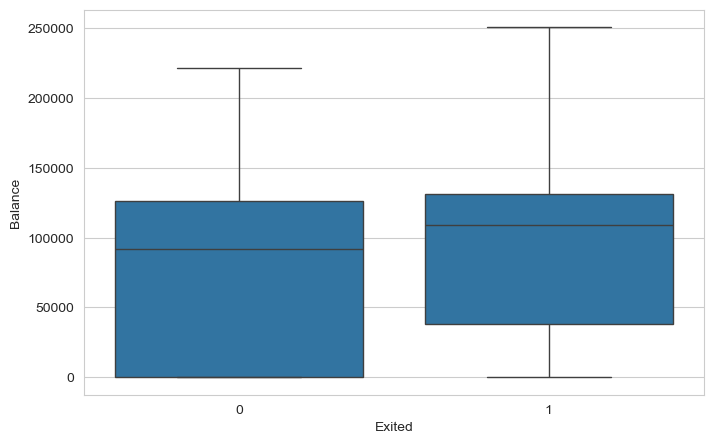

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.show()

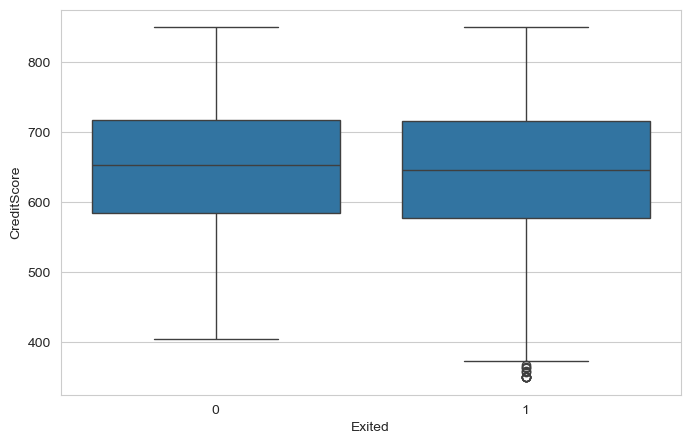

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=df
)

plt.show()

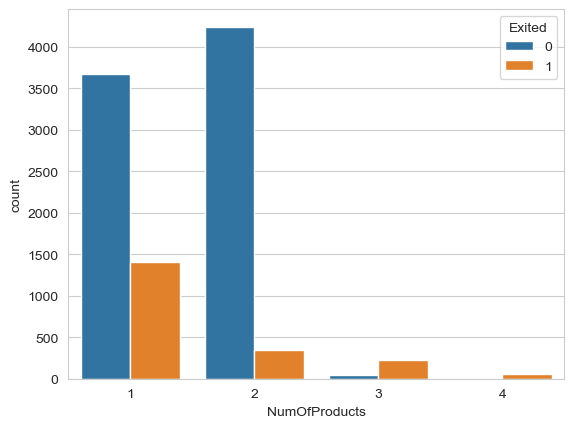

In [30]:
sns.countplot(
    x='NumOfProducts',
    hue='Exited',
    data=df
)

plt.show()

In [31]:
temp_df = df.copy()#CORRREATTION ANALYSIS

temp_df['Gender'] = temp_df['Gender'].map({
    'Male':1,
    'Female':0
})

temp_df = pd.get_dummies(
    temp_df,
    columns=['Geography'],
    drop_first=True
)

In [32]:
corr = temp_df.corr()

corr

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


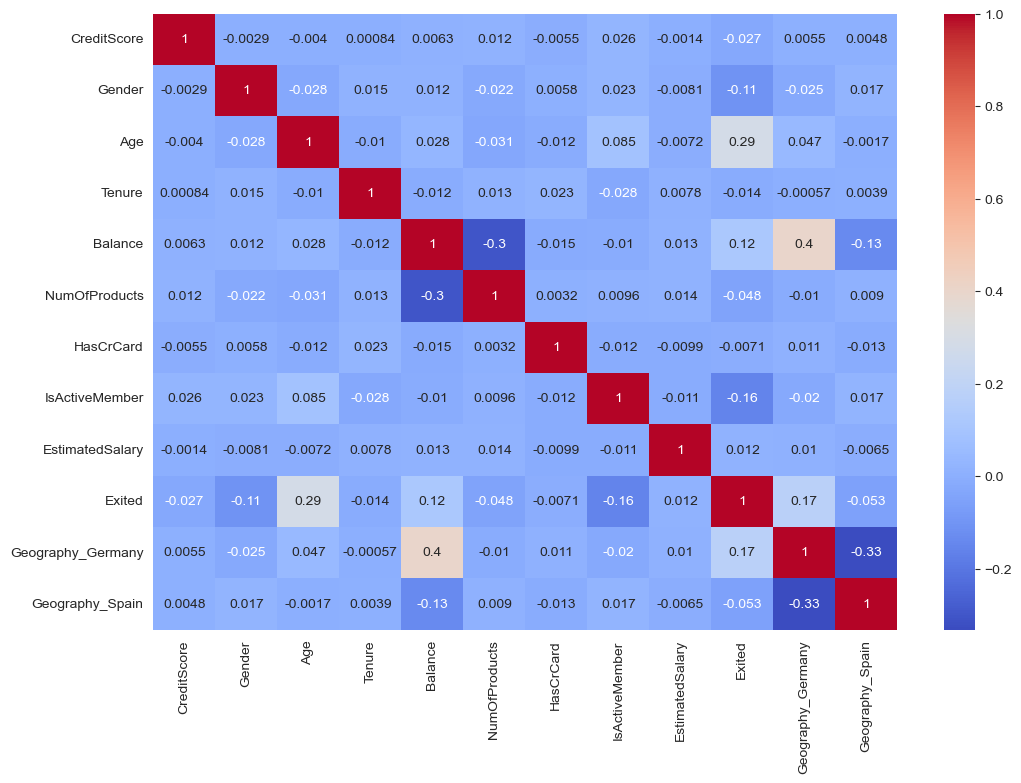

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

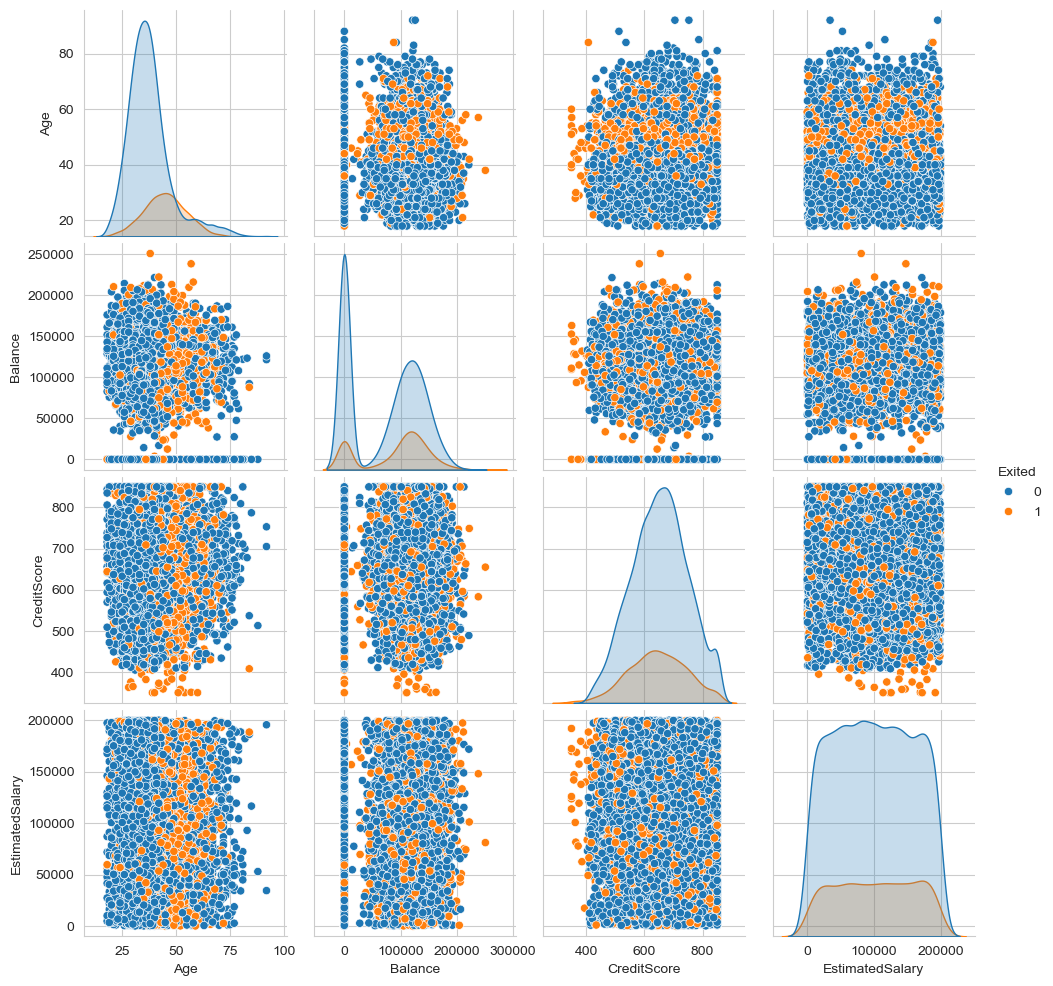

In [34]:
sns.pairplot(
    df[['Age',
        'Balance',
        'CreditScore',
        'EstimatedSalary',
        'Exited']],
    hue='Exited'
)

plt.show()

In [35]:
bins = [18,30,40,50,60,100]

labels = [
    '18-30',
    '31-40',
    '41-50',
    '51-60',
    '60+'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

C:\Users\Deon Sumithra\AppData\Local\Temp\ipykernel_18480\2261346001.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby(


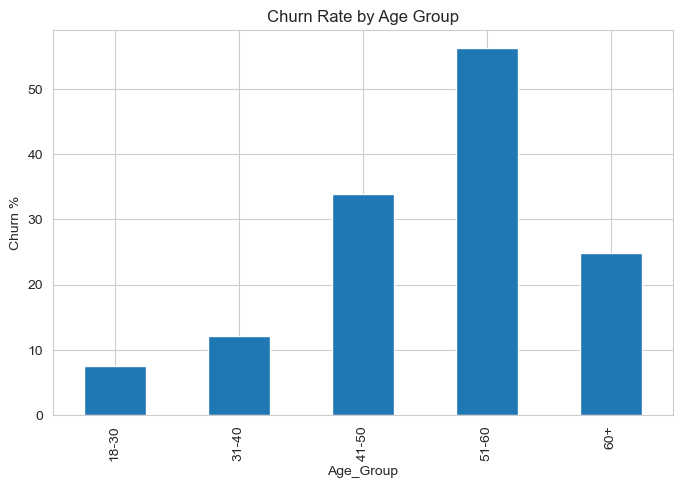

In [36]:
age_churn = df.groupby(
    'Age_Group'
)['Exited'].mean()*100

age_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Churn %")
plt.title("Churn Rate by Age Group")
plt.show()

Top 5 Key Findings from EDA

1. Customer Churn Rate

Out of 10,000 customers, approximately 2,037 customers (20.37%) have churned.
About 7,963 customers (79.63%) remained with the bank.

2. Germany Has the Highest Churn

Customers from Germany show the highest churn rate among all countries.
Geography appears to be an important factor influencing customer retention.

3. Age Strongly Impacts Churn

Customers who churn are generally older than customers who stay.
Age is one of the strongest predictors of customer churn.

4. Inactive Members Are More Likely to Leave

Customers with IsActiveMember = 0 have a significantly higher churn rate.
Active engagement plays a major role in customer retention.

5. Higher Balance Customers Tend to Churn More

Customers maintaining higher account balances are more likely to leave the bank.
Losing these customers can have a greater financial impact on the business.